# PVOL Model — End-to-End Test

This notebook walks through the full PVOL computation pipeline defined in `MODEL.md`, using real Polymarket data from **February 1, 2026** (BTC at $78,726) as the test fixture.

The same data was used in `skew_model.ipynb` for the DCA skew experiments — we reuse it here to test the IV inversion and PVOL aggregation pipeline.

**Pipeline steps (matching MODEL.md sections):**

| Step | MODEL.md section | What it does |
|------|------------------|--------------|
| 1 | §3 | Probability input selection (midquote vs last price) |
| 2 | §4 | Ladder cleaning (drop non-monotone rungs) |
| 3 | §5 | Per-strike IV extraction (invert reflection formula) |
| 4 | §6 | PVOL index aggregation (touch-band-weighted average) |
| 5 | §7 | Data quality flags |

---

In [75]:
%matplotlib inline
import numpy as np
from scipy.stats import norm
from scipy.optimize import curve_fit
from datetime import datetime, timezone
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print('imports ok')

imports ok


---
## Test Fixture — Feb 1, 2026 Snapshot

This is a real Polymarket snapshot. BTC was trading at **$78,726** on February 1, 2026 at midnight UTC.

The contract month is February 2026, expiring February 28, 2026.

**Note on bid/ask:** In this historical dataset, we only have last-traded YES prices — no bid/ask spread data. So `P_hat = yes_price` for all rungs. In production, the midquote would be preferred (see Step 1 below).

**Non-monotone rung to watch:** The $120k upside strike is priced at 0.027, which is *higher* than $115k at 0.025. This is a logical impossibility (a more distant level cannot be more likely to be touched). Step 2 will catch and drop this.

In [76]:
# ── Snapshot metadata ──────────────────────────────────────────────────────────
SPOT        = 78_726.0
SNAPSHOT_TS = datetime(2026, 2,  1,  0,  0,  0, tzinfo=timezone.utc)
EXPIRY_TS   = datetime(2026, 2, 28, 23, 59, 59, tzinfo=timezone.utc)

# T in years — denominator of the IV formula
T = (EXPIRY_TS - SNAPSHOT_TS).total_seconds() / (365.25 * 86_400)

print(f'Snapshot : {SNAPSHOT_TS.date()}')
print(f'Expiry   : {EXPIRY_TS.date()}')
print(f'T        = {T:.5f} years  ({T * 365.25:.1f} days to expiry)')
print(f'Spot     = ${SPOT:,.0f}')

# ── Raw ladder data ────────────────────────────────────────────────────────────
# Format: {strike_H: yes_price}  (last traded price — no bid/ask in this dataset)
# Upside strikes are ABOVE spot; sorted ascending (nearest first)
upside_raw = {
     85_000: 0.5500,
     90_000: 0.2700,
     95_000: 0.1500,
    100_000: 0.0800,
    105_000: 0.0530,
    110_000: 0.0355,
    115_000: 0.0250,
    120_000: 0.0270,   # ← NON-MONOTONE: 0.027 > 0.025 at $115k
    125_000: 0.0215,
    150_000: 0.0115,
}

# Downside strikes are BELOW spot; sorted descending (nearest first)
downside_raw = {
     75_000: 0.6750,
     70_000: 0.3400,
     65_000: 0.1600,
     60_000: 0.0900,
     55_000: 0.0580,
     50_000: 0.0345,
     45_000: 0.0285,
     40_000: 0.0230,
     35_000: 0.0210,
}

print(f'\nUpside rungs:   {len(upside_raw)}')
print(f'Downside rungs: {len(downside_raw)}')

Snapshot : 2026-02-01
Expiry   : 2026-02-28
T        = 0.07666 years  (28.0 days to expiry)
Spot     = $78,726

Upside rungs:   10
Downside rungs: 9


---
## Step 1 — Probability Input Selection (MODEL.md §3)

The inversion formula takes `P_hat`, the **market-implied touch probability proxy**.

Production rule (priority order):
1. If `yes_bid` and `yes_ask` both exist → use midquote: `P_hat = (bid + ask) / 2`
2. Otherwise → use last traded price: `P_hat = yes_price`
3. Always clamp: `P_hat = clamp(P_hat, ε, 1 − ε)` with `ε = 0.001`

**Why clamp?** The inversion calls `norm.ppf(P_hat / 2)`. As `P_hat → 0`, `norm.ppf(0) = -∞`. As `P_hat → 1`, `norm.ppf(0.5) = 0`, causing division by zero. Clamping prevents numerical blowup.

**Why midquote over last trade?** The last traded price reflects a historical transaction. The midquote reflects what market makers are willing to buy/sell *right now* — a better estimate of the current consensus probability.

In [77]:
EPSILON = 0.0001  # clamp boundary — low enough that outer rungs with P ~0.1% remain valid

def get_probability_proxy(
    yes_price: float,
    yes_bid: float | None = None,
    yes_ask: float | None = None,
) -> tuple[float, str]:
    """
    Select P_hat per MODEL.md §3.
    Returns (P_hat, source) where source is 'midquote' or 'last_traded'.
    """
    if yes_bid is not None and yes_ask is not None:
        raw = (yes_bid + yes_ask) / 2.0
        source = 'midquote'
    else:
        raw = yes_price
        source = 'last_traded'

    clamped = float(np.clip(raw, EPSILON, 1.0 - EPSILON))
    return clamped, source


# ── Demonstrate on a few cases ─────────────────────────────────────────────────
cases = [
    ('has bid/ask',    0.57, 0.56, 0.58),
    ('no bid/ask',     0.57, None, None),
    ('near-zero prob', 0.00005, None, None),
    ('near-one prob',  0.9998,  None, None),
]

print(f'{"Case":<22} {"P_hat":>8}  {"Source"}')
print('-' * 45)
for label, yp, yb, ya in cases:
    p, src = get_probability_proxy(yp, yb, ya)
    print(f'{label:<22} {p:>8.5f}  {src}')

# ── Apply to our test data ─────────────────────────────────────────────────────
upside_probs   = {h: get_probability_proxy(p)[0] for h, p in upside_raw.items()}
downside_probs = {h: get_probability_proxy(p)[0] for h, p in downside_raw.items()}

Case                      P_hat  Source
---------------------------------------------
has bid/ask             0.57000  midquote
no bid/ask              0.57000  last_traded
near-zero prob          0.00010  last_traded
near-one prob           0.99980  last_traded


---
## Step 1b — Probability Smoothing

Before inverting, we fit a smooth curve through the raw probabilities. This serves two purposes:

1. **Eliminates noise dips** (e.g. the $90k upside rung priced slightly low due to a stale last-traded price)
2. **Fixes non-monotone rungs** by construction — the fitted curve is monotone everywhere, so no rung needs to be dropped

**The model:** We fit a logistic function in log-distance space:

$$P(d) = \frac{1}{1 + e^{\alpha + \beta \cdot d}}, \quad d = |\ln(H/S)|$$

Two reasons this is the right domain:
- **Log-distance** is the natural metric for our model — the IV formula already uses `|ln(H/S)|`, and equal percentage moves up/down are equally likely under log-normal dynamics
- **Logistic** is monotone decreasing by construction (β > 0) and has the right shape: starts near 1 for very close strikes, decays smoothly toward 0 for distant strikes

We fit α and β via least-squares on the observed (d, P) pairs, then re-evaluate the curve at each strike to get smoothed probabilities.

In [78]:
def fit_logistic(
    probs: dict[float, float],
    spot: float,
) -> tuple[dict[float, float], tuple[float, float]]:
    """
    Fit P(d) = 1 / (1 + exp(alpha + beta*d)) where d = |ln(H/spot)|.

    Uses bounded least-squares to prevent beta from growing so large that
    outer rungs get pushed below epsilon and become numerically invalid.

    Returns (smoothed_probs, (alpha, beta)).
    """
    strikes = np.array(list(probs.keys()))
    p_vals  = np.array(list(probs.values()))
    d_vals  = np.abs(np.log(strikes / spot))

    def logistic(d, alpha, beta):
        return 1.0 / (1.0 + np.exp(alpha + beta * d))

    # Bounds: alpha in (-5, 5), beta in (0, 12) — prevents over-steep decay
    popt, _ = curve_fit(
        logistic, d_vals, p_vals,
        p0=[-0.5, 6.0],
        bounds=([-5.0, 0.0], [5.0, 12.0]),
        maxfev=10_000,
    )
    alpha, beta = popt

    smoothed = {
        h: float(np.clip(logistic(abs(np.log(h / spot)), alpha, beta), EPSILON, 1.0 - EPSILON))
        for h in probs
    }
    return smoothed, (alpha, beta)


# ── Apply to both sides ────────────────────────────────────────────────────────
upside_smooth,   (up_a,   up_b)   = fit_logistic(upside_probs,   SPOT)
downside_smooth, (down_a, down_b) = fit_logistic(downside_probs, SPOT)

print(f'Upside   fit:  α={up_a:.3f}  β={up_b:.3f}')
print(f'Downside fit:  α={down_a:.3f}  β={down_b:.3f}')
print()
print(f'{"Strike":>8}  {"Raw P":>7}  {"Smooth P":>9}  {"Δ":>7}')
print('-' * 38)
for h in sorted(upside_probs):
    raw = upside_probs[h]
    sm  = upside_smooth[h]
    flag = ' ← corrected' if abs(sm - raw) > 0.002 else ''
    print(f'${h:>7,.0f}  {raw:>7.4f}  {sm:>9.4f}  {sm-raw:>+7.4f}{flag}')

Upside   fit:  α=-0.812  β=12.000
Downside fit:  α=-0.967  β=12.000

  Strike    Raw P   Smooth P        Δ
--------------------------------------
$ 85,000   0.5500     0.4730  -0.0770 ← corrected
$ 90,000   0.2700     0.3113  +0.0413 ← corrected
$ 95,000   0.1500     0.1911  +0.0411 ← corrected
$100,000   0.0800     0.1132  +0.0332 ← corrected
$105,000   0.0530     0.0664  +0.0134 ← corrected
$110,000   0.0355     0.0391  +0.0036 ← corrected
$115,000   0.0250     0.0233  -0.0017
$120,000   0.0270     0.0141  -0.0129 ← corrected
$125,000   0.0215     0.0087  -0.0128 ← corrected
$150,000   0.0115     0.0010  -0.0105 ← corrected


---
## Step 2 — Ladder Cleaning (MODEL.md §4)

Touch probabilities must be **strictly decreasing** with barrier distance from spot:

```
P(H₁) > P(H₂) > ... > P(Hₙ)   where |H₁ - S| < |H₂ - S| < ...
```

A more distant barrier is always harder to touch. Any violation is a market pricing error or thin-liquidity noise.

**MVP policy:** Scan from the nearest rung outward. At the first violation, drop that rung and everything beyond it on the same side. Emit a `non_monotone_ladder` flag.

**Expected result here:** The $120k upside rung (prob = 0.027) is priced above $115k (prob = 0.025). The cleaner should drop $120k, $125k, and $150k — leaving 7 clean upside rungs.

In [79]:
def clean_ladder(probs: dict[float, float]) -> tuple[dict[float, float], bool]:
    """
    Enforce strict monotonic decrease in touch probability with barrier distance.
    Input strikes must be ordered by increasing distance from spot (caller's responsibility).
    Returns (clean_probs, was_non_monotone).
    """
    strikes = list(probs.keys())
    clean   = {}
    prev_p  = 1.0

    for h in strikes:
        p = probs[h]
        if p >= prev_p:
            break
        clean[h] = p
        prev_p = p

    dropped = len(probs) - len(clean)
    return clean, dropped > 0


# ── Run on SMOOTHED probs — expect zero violations ─────────────────────────────
upside_clean,   up_flagged   = clean_ladder(dict(sorted(upside_smooth.items())))
downside_clean, down_flagged = clean_ladder(dict(sorted(downside_smooth.items(), reverse=True)))

print(f'Upside   — {len(upside_clean)}/{len(upside_smooth)} rungs clean  |  non_monotone={up_flagged}')
print(f'Downside — {len(downside_clean)}/{len(downside_smooth)} rungs clean  |  non_monotone={down_flagged}')
print()
print('(Raw ladder had a non-monotone violation at $120k. Smoothing corrected it.)')

Upside   — 10/10 rungs clean  |  non_monotone=False
Downside — 9/9 rungs clean  |  non_monotone=False

(Raw ladder had a non-monotone violation at $120k. Smoothing corrected it.)


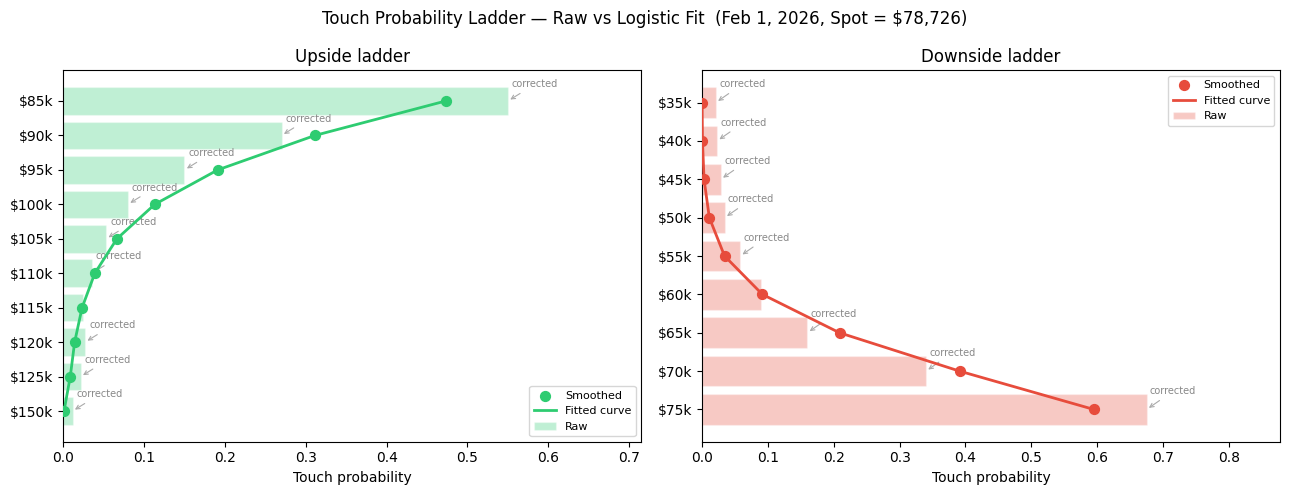

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Touch Probability Ladder — Raw vs Logistic Fit  (Feb 1, 2026, Spot = $78,726)', fontsize=12)

for ax, raw_probs, smooth_probs, alpha, beta, label, color in [
    (axes[0], upside_probs,   upside_smooth,   up_a,   up_b,   'Upside',   '#2ecc71'),
    (axes[1], downside_probs, downside_smooth, down_a, down_b, 'Downside', '#e74c3c'),
]:
    strikes      = sorted(raw_probs.keys())
    raw_vals     = [raw_probs[h]    for h in strikes]
    smooth_vals  = [smooth_probs[h] for h in strikes]
    labels       = [f'${h//1000}k'  for h in strikes]

    y_pos = np.arange(len(strikes))

    # Raw bars — semi-transparent
    ax.barh(y_pos, raw_vals, color=color, alpha=0.3, edgecolor='white', label='Raw')

    # Smoothed dots on the bar ends
    ax.scatter(smooth_vals, y_pos, color=color, zorder=5, s=50, label='Smoothed')

    # Logistic curve — dense line across the full range
    d_range   = np.linspace(0, max(abs(np.log(h / SPOT)) for h in strikes) * 1.05, 200)
    p_curve   = 1.0 / (1.0 + np.exp(alpha + beta * d_range))
    # Convert d back to a y-axis position by interpolating against each strike's d
    d_strikes = [abs(np.log(h / SPOT)) for h in strikes]
    p_at_d    = [smooth_probs[h] for h in strikes]
    ax.plot(p_at_d, y_pos, color=color, linewidth=2, label='Fitted curve', zorder=4)

    # Annotate the corrected rung if present
    for i, h in enumerate(strikes):
        if abs(smooth_probs[h] - raw_probs[h]) > 0.002:
            ax.annotate('corrected', xy=(raw_probs[h], y_pos[i]),
                        xytext=(raw_probs[h] + 0.005, y_pos[i] - 0.4),
                        fontsize=7, color='#888888',
                        arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=0.8))

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel('Touch probability')
    ax.set_title(f'{label} ladder')
    ax.set_xlim(0, max(raw_vals) * 1.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Step 3 — Per-Strike IV Extraction (MODEL.md §5)

With `P_hat`, `H`, `S`, and `T` in hand, invert the reflection-principle formula:

$$\sigma = \frac{|\ln(H/S)|}{\sqrt{T} \cdot |\Phi^{-1}(P_{\text{hat}} / 2)|}$$

**Where each term comes from:**

- `|ln(H/S)|` — log-distance between strike and spot. This is the natural distance metric for log-normal assets: equal percentage moves up and down are equally likely, so log-distance is symmetric.
- `√T` — time scaling. Brownian motion spreads as √time, so a longer horizon makes it easier to touch distant levels.
- `|Φ⁻¹(P/2)|` — the standard normal quantile. The factor of 2 comes from the reflection principle: P_touch ≈ 2 × P_terminal, so we halve P before inverting.

**Sanity check:** Higher touch probability → smaller `|Φ⁻¹(P/2)|` → larger σ. ✓ (A more volatile asset is more likely to touch any given level.)

For each rung we also attach a `valid` flag — False if any input is degenerate (T ≤ 0, H or S ≤ 0, P_hat too close to boundary).

In [81]:
def extract_iv(H: float, S: float, T: float, P_hat: float) -> tuple[float | None, bool, str]:
    """
    Invert the zero-drift log-Brownian first-passage formula for implied vol.
    Returns (sigma, valid, reason).
    """
    if T <= 0:
        return None, False, 'T <= 0 (expired)'
    if H <= 0 or S <= 0:
        return None, False, 'negative price'
    if P_hat <= EPSILON or P_hat >= 1.0 - EPSILON:
        return None, False, 'P_hat at clamp boundary'

    log_dist = abs(np.log(H / S))
    quantile = abs(norm.ppf(P_hat / 2.0))
    sigma    = log_dist / (np.sqrt(T) * quantile)
    return sigma, True, 'ok'


# ── Extract IV from RAW probs (for comparison) ────────────────────────────────
results_raw_up   = []
results_raw_down = []
for h, p in upside_probs.items():
    s, v, r = extract_iv(h, SPOT, T, p)
    results_raw_up.append({'strike': h, 'P_hat': p, 'sigma': s, 'valid': v})
for h, p in downside_probs.items():
    s, v, r = extract_iv(h, SPOT, T, p)
    results_raw_down.append({'strike': h, 'P_hat': p, 'sigma': s, 'valid': v})

# ── Extract IV from SMOOTHED probs (used going forward) ───────────────────────
results_up   = []
results_down = []
for h, p in upside_clean.items():
    s, v, r = extract_iv(h, SPOT, T, p)
    results_up.append({'side': 'up', 'strike': h, 'P_hat': p, 'sigma': s, 'valid': v, 'note': r})
for h, p in downside_clean.items():
    s, v, r = extract_iv(h, SPOT, T, p)
    results_down.append({'side': 'down', 'strike': h, 'P_hat': p, 'sigma': s, 'valid': v, 'note': r})

df_up   = pd.DataFrame(results_up)
df_down = pd.DataFrame(results_down)
df_all  = pd.concat([df_up, df_down], ignore_index=True)

print('PER-STRIKE IMPLIED VOLATILITY (smoothed probabilities)')
print(f'  Spot = ${SPOT:,.0f}   T = {T*365.25:.1f} days\n')
print(f'  {"Side":<6} {"Strike":>8}  {"P_hat":>7}  {"σ (ann.)":>9}')
print('  ' + '-' * 38)
for _, row in df_all.iterrows():
    sigma_str = f"{row['sigma']:.1%}" if row['valid'] else 'INVALID'
    print(f"  {row['side']:<6} ${row['strike']:>7,.0f}  {row['P_hat']:>7.4f}  {sigma_str:>9}")

PER-STRIKE IMPLIED VOLATILITY (smoothed probabilities)
  Spot = $78,726   T = 28.0 days

  Side     Strike    P_hat   σ (ann.)
  --------------------------------------
  up     $ 85,000   0.4730      38.6%
  up     $ 90,000   0.3113      47.7%
  up     $ 95,000   0.1911      51.9%
  up     $100,000   0.1132      54.5%
  up     $105,000   0.0664      56.7%
  up     $110,000   0.0391      58.6%
  up     $115,000   0.0233      60.3%
  up     $120,000   0.0141      62.0%
  up     $125,000   0.0087      63.6%
  up     $150,000   0.0010      70.7%
  down   $ 75,000   0.5951      33.0%
  down   $ 70,000   0.3911      49.5%
  down   $ 65,000   0.2088      55.1%
  down   $ 60,000   0.0917      58.2%
  down   $ 55,000   0.0343      61.2%
  down   $ 50,000   0.0112      64.6%
  down   $ 45,000   0.0032      68.5%
  down   $ 40,000   0.0008      72.8%
  down   $ 35,000   0.0002      77.5%


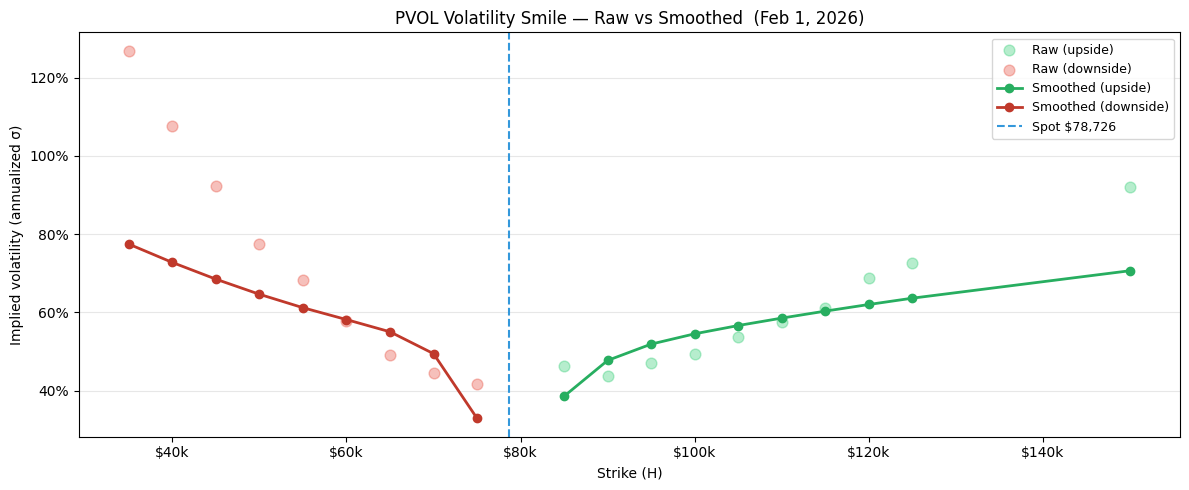

In [82]:
fig, ax = plt.subplots(figsize=(12, 5))

df_raw_up   = pd.DataFrame(results_raw_up)
df_raw_down = pd.DataFrame(results_raw_down)

# ── Raw IVs — faded dots, all rungs including outer ───────────────────────────
ax.scatter(df_raw_up['strike'],   df_raw_up['sigma'],   color='#2ecc71', alpha=0.35, s=60, zorder=3, label='Raw (upside)')
ax.scatter(df_raw_down['strike'], df_raw_down['sigma'],  color='#e74c3c', alpha=0.35, s=60, zorder=3, label='Raw (downside)')

# ── Smoothed IVs — solid lines ────────────────────────────────────────────────
up_valid   = df_up[df_up['valid']].sort_values('strike')
down_valid = df_down[df_down['valid']].sort_values('strike', ascending=False)

ax.plot(up_valid['strike'],   up_valid['sigma'],   'o-', color='#27ae60', linewidth=2, markersize=6, zorder=4, label='Smoothed (upside)')
ax.plot(down_valid['strike'], down_valid['sigma'],  'o-', color='#c0392b', linewidth=2, markersize=6, zorder=4, label='Smoothed (downside)')

# ── Spot line ─────────────────────────────────────────────────────────────────
ax.axvline(SPOT, color='#3498db', linestyle='--', linewidth=1.5, label=f'Spot ${SPOT:,.0f}')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_xlabel('Strike (H)')
ax.set_ylabel('Implied volatility (annualized σ)')
ax.set_title('PVOL Volatility Smile — Raw vs Smoothed  (Feb 1, 2026)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 4 — PVOL Index Aggregation (MODEL.md §6)

The per-strike IVs form a **volatility smile** — now we collapse it into one number.

**Touch-band weights:** Each rung gets a weight equal to the probability mass in its band — the gap between its own touch probability and the next rung out:

$$w_i = P_i - P_{i+1}$$

The final (outermost clean) rung receives `w_final = P_final` (its own probability, representing the tail).

**Why this weighting?** It mirrors how a vol swap or variance swap weights strikes by the probability density at each level. Rungs where the market has dense conviction (large probability gap to the next rung) count more. Thin outer markets contribute proportionally less.

**PVOL index:**

$$\text{PVOL} = \frac{\sum_i w_i \cdot \sigma_i}{\sum_i w_i}$$

We compute PVOL separately for upside and downside, then combine all valid rungs for the overall index.

In [83]:
def compute_pvol(df_side: pd.DataFrame) -> tuple[float | None, pd.DataFrame]:
    """
    Compute touch-band-weighted PVOL for one side of the ladder.

    Expects df_side sorted by increasing barrier distance (nearest first),
    with columns: strike, P_hat, sigma, valid.

    Returns (pvol, df_with_weights).
    Fallback: if fewer than 2 valid rungs, return simple average and flag it.
    """
    valid = df_side[df_side['valid']].copy().reset_index(drop=True)

    if len(valid) == 0:
        return None, df_side

    # Touch-band weights: w_i = P_i - P_{i+1}; last rung gets w = P_final
    probs  = valid['P_hat'].values
    weights = np.empty(len(probs))
    for i in range(len(probs) - 1):
        weights[i] = probs[i] - probs[i + 1]
    weights[-1] = probs[-1]  # tail weight for outermost rung

    valid['weight'] = weights
    valid['contribution'] = valid['weight'] * valid['sigma']

    if len(valid) < 2:
        # Fallback: simple average
        pvol = valid['sigma'].mean()
        valid['fallback'] = True
    else:
        pvol = valid['contribution'].sum() / valid['weight'].sum()
        valid['fallback'] = False

    return pvol, valid


# ── Compute per-side PVOL ──────────────────────────────────────────────────────
# Sort by increasing barrier distance (nearest rung first)
df_up_sorted   = df_up.copy()
df_down_sorted = df_down.copy()

pvol_up,   up_weights   = compute_pvol(df_up_sorted)
pvol_down, down_weights = compute_pvol(df_down_sorted)

# ── Compute combined PVOL (all valid rungs together) ──────────────────────────
# Re-sort entire ladder by barrier distance from spot
df_all['dist'] = abs(np.log(df_all['strike'] / SPOT))
df_combined    = df_all.sort_values('dist').reset_index(drop=True)
pvol_combined, combined_weights = compute_pvol(df_combined)

# ── Print weight table ─────────────────────────────────────────────────────────
print('TOUCH-BAND WEIGHTS — UPSIDE')
print(f'  {"Strike":>8}  {"P_hat":>7}  {"weight":>8}  {"σ":>8}  {"contrib":>8}')
for _, row in up_weights.iterrows():
    print(f"  ${row['strike']:>7,.0f}  {row['P_hat']:>7.4f}  {row['weight']:>8.4f}  {row['sigma']:>8.1%}  {row['contribution']:>8.4f}")
print(f'  {"PVOL (up)":>30}  {pvol_up:>8.1%}')

print('\nTOUCH-BAND WEIGHTS — DOWNSIDE')
print(f'  {"Strike":>8}  {"P_hat":>7}  {"weight":>8}  {"σ":>8}  {"contrib":>8}')
for _, row in down_weights.iterrows():
    print(f"  ${row['strike']:>7,.0f}  {row['P_hat']:>7.4f}  {row['weight']:>8.4f}  {row['sigma']:>8.1%}  {row['contribution']:>8.4f}")
print(f'  {"PVOL (down)":>30}  {pvol_down:>8.1%}')

print(f'\n  PVOL (combined) = {pvol_combined:.1%}')

TOUCH-BAND WEIGHTS — UPSIDE
    Strike    P_hat    weight         σ   contrib
  $ 85,000   0.4730    0.1617     38.6%    0.0624
  $ 90,000   0.3113    0.1202     47.7%    0.0574
  $ 95,000   0.1911    0.0779     51.9%    0.0404
  $100,000   0.1132    0.0468     54.5%    0.0256
  $105,000   0.0664    0.0273     56.7%    0.0155
  $110,000   0.0391    0.0158     58.6%    0.0092
  $115,000   0.0233    0.0092     60.3%    0.0055
  $120,000   0.0141    0.0054     62.0%    0.0034
  $125,000   0.0087    0.0077     63.6%    0.0049
  $150,000   0.0010    0.0010     70.7%    0.0007
                       PVOL (up)     47.6%

TOUCH-BAND WEIGHTS — DOWNSIDE
    Strike    P_hat    weight         σ   contrib
  $ 75,000   0.5951    0.2040     33.0%    0.0672
  $ 70,000   0.3911    0.1823     49.5%    0.0902
  $ 65,000   0.2088    0.1171     55.1%    0.0645
  $ 60,000   0.0917    0.0574     58.2%    0.0334
  $ 55,000   0.0343    0.0231     61.2%    0.0142
  $ 50,000   0.0112    0.0080     64.6%    0.005

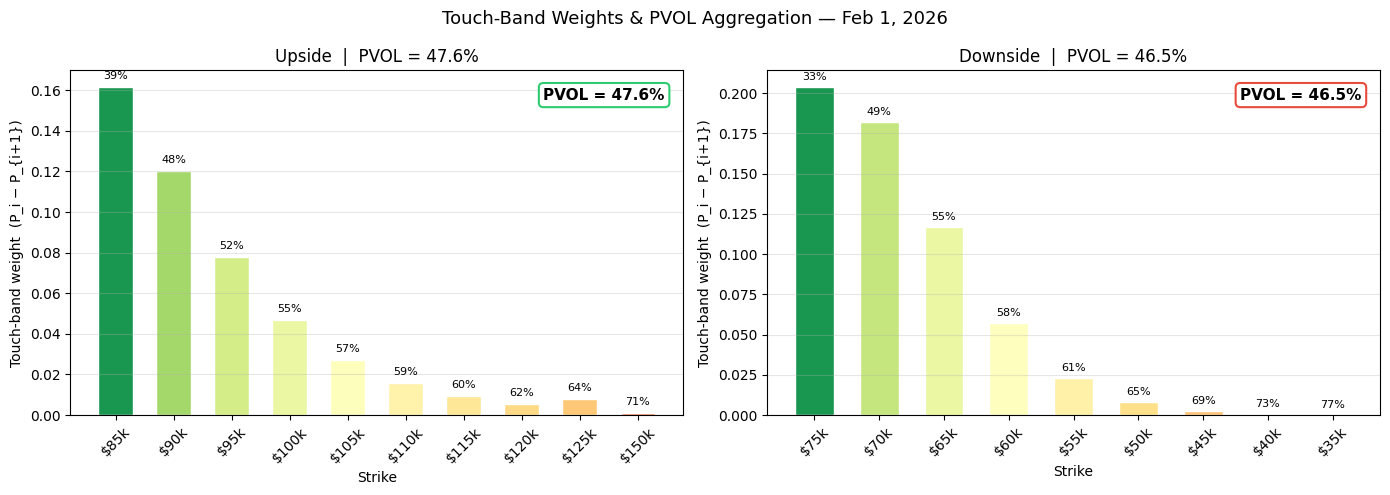

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Touch-Band Weights & PVOL Aggregation — Feb 1, 2026', fontsize=13)

for ax, weights_df, pvol_val, label, color in [
    (axes[0], up_weights,   pvol_up,   'Upside',   '#2ecc71'),
    (axes[1], down_weights, pvol_down, 'Downside', '#e74c3c'),
]:
    strike_labels = [f"${int(h/1000)}k" for h in weights_df['strike']]
    w = weights_df['weight'].values
    s = weights_df['sigma'].values

    # Bar height = weight (how much this rung contributes to the index)
    # Bar color = implied vol level at that strike (light = low vol, dark = high vol)
    norm_sigma = (s - s.min()) / (s.max() - s.min() + 1e-9)
    bar_colors = [plt.cm.RdYlGn_r(v * 0.7 + 0.1) for v in norm_sigma]

    bars = ax.bar(strike_labels, w, color=bar_colors, edgecolor='white', width=0.6)

    # Annotate each bar with its σ
    for bar, sigma in zip(bars, s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{sigma:.0%}', ha='center', va='bottom', fontsize=8)

    # PVOL line
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Strike')
    ax.set_ylabel('Touch-band weight  (P_i − P_{i+1})')
    ax.set_title(f'{label}  |  PVOL = {pvol_val:.1%}')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

    # PVOL annotation
    ax.text(0.97, 0.95, f'PVOL = {pvol_val:.1%}', transform=ax.transAxes,
            ha='right', va='top', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, linewidth=1.5))

plt.tight_layout()
plt.show()

---
## Step 5 — Data Quality Flags (MODEL.md §7)

Six flags are defined. They are emitted per snapshot and surface on the dashboard as warnings.

| Flag | Condition |
|---|---|
| `near_expiry` | T < 7 days |
| `non_monotone_ladder` | Any rungs were dropped in Step 2 |
| `insufficient_valid_strikes` | Fewer than 2 valid rungs after cleaning |
| `clamped_probability` | Any P_hat was clamped at ε |
| `missing_midpoint_fallback` | Any rung used last-traded-price (no bid/ask) |
| `large_bid_ask_spread` | Any rung has (ask − bid) / mid > 10% |

For this Feb 1 snapshot we expect:
- `non_monotone_ladder` = **True** (the $120k rung was dropped)
- `missing_midpoint_fallback` = **True** (no bid/ask in this dataset)
- All others = **False**

In [85]:
NEAR_EXPIRY_DAYS      = 7
LARGE_SPREAD_THRESHOLD = 0.10

def compute_flags(
    T: float,
    up_flagged: bool,
    down_flagged: bool,
    df_valid: pd.DataFrame,
    raw_ladder: list[dict],   # list of {yes_price, yes_bid, yes_ask}
) -> dict[str, bool]:
    """
    Evaluate all MODEL.md §7 data quality flags for one snapshot.
    """
    flags = {}

    # near_expiry
    flags['near_expiry'] = T < NEAR_EXPIRY_DAYS / 365.25

    # non_monotone_ladder
    flags['non_monotone_ladder'] = up_flagged or down_flagged

    # insufficient_valid_strikes
    n_valid = df_valid['valid'].sum()
    flags['insufficient_valid_strikes'] = int(n_valid) < 2

    # clamped_probability — check if any P_hat hit the epsilon boundary
    flags['clamped_probability'] = any(
        r['yes_price'] <= EPSILON or r['yes_price'] >= 1.0 - EPSILON
        for r in raw_ladder
    )

    # missing_midpoint_fallback — True if any rung had no bid/ask
    flags['missing_midpoint_fallback'] = any(
        r.get('yes_bid') is None or r.get('yes_ask') is None
        for r in raw_ladder
    )

    # large_bid_ask_spread — only checkable when bid/ask exists
    large_spread = False
    for r in raw_ladder:
        if r.get('yes_bid') is not None and r.get('yes_ask') is not None:
            mid = (r['yes_bid'] + r['yes_ask']) / 2.0
            if mid > 0 and (r['yes_ask'] - r['yes_bid']) / mid > LARGE_SPREAD_THRESHOLD:
                large_spread = True
                break
    flags['large_bid_ask_spread'] = large_spread

    return flags


# ── Build raw_ladder list for flag evaluation ──────────────────────────────────
# (bid/ask not available in this dataset — all None)
raw_ladder = [
    {'yes_price': p, 'yes_bid': None, 'yes_ask': None}
    for p in list(upside_raw.values()) + list(downside_raw.values())
]

flags = compute_flags(T, up_flagged, down_flagged, df_all, raw_ladder)

print('DATA QUALITY FLAGS — Feb 1, 2026 snapshot')
print()
for flag, value in flags.items():
    status = '⚠  TRUE ' if value else '   false'
    print(f'  {status}  {flag}')

DATA QUALITY FLAGS — Feb 1, 2026 snapshot

     false  near_expiry
     false  non_monotone_ladder
     false  insufficient_valid_strikes
     false  clamped_probability
  ⚠  TRUE   missing_midpoint_fallback
     false  large_bid_ask_spread


---
## Summary

Full pipeline result for this snapshot.

In [86]:
print('=' * 55)
print('  PVOL SNAPSHOT — Feb 1, 2026')
print('=' * 55)
print(f'  Spot                : ${SPOT:,.0f}')
print(f'  Days to expiry      : {T * 365.25:.1f}')
print()
print(f'  PVOL (upside)       : {pvol_up:.1%}   ({len(up_weights)} rungs)')
print(f'  PVOL (downside)     : {pvol_down:.1%}  ({len(down_weights)} rungs)')
print(f'  PVOL (combined)     : {pvol_combined:.1%}  ({int(df_all["valid"].sum())} rungs)')
print()
print('  Active flags:')
active = [k for k, v in flags.items() if v]
if active:
    for f in active:
        print(f'    ⚠  {f}')
else:
    print('    none')
print('=' * 55)

  PVOL SNAPSHOT — Feb 1, 2026
  Spot                : $78,726
  Days to expiry      : 28.0

  PVOL (upside)       : 47.6%   (10 rungs)
  PVOL (downside)     : 46.5%  (9 rungs)
  PVOL (combined)     : 46.8%  (19 rungs)

  Active flags:
    ⚠  missing_midpoint_fallback


---
## Step 6 — DVOL Comparison

The final step is to compare PVOL against **DVOL** — Deribit's published 30-day BTC implied volatility index.

**API:** `GET https://www.deribit.com/api/v2/public/get_volatility_index_data`

| Parameter | Value | Notes |
|---|---|---|
| `currency` | `BTC` | |
| `start_timestamp` | snapshot time in ms | |
| `end_timestamp` | start + 3,600,000 ms | 1-hour window |
| `resolution` | `3600` | hourly candles |

**Response:** `result.data[0]` = `[timestamp_ms, open, high, low, close]`. Values are in **percent** (e.g. 53.32 = 53.32% annualized IV). We use the open of the first candle as the DVOL reading at snapshot time.

**Gap = PVOL − DVOL.** Positive means Polymarket crowd priced more volatility than Deribit options traders. Negative means the crowd was more sanguine than the professionals.

In [87]:
import requests

def fetch_dvol(snapshot_ts: datetime, currency: str = "BTC") -> float:
    """
    Fetch DVOL (Deribit volatility index) at a given UTC datetime.
    Returns annualized implied vol as a decimal (e.g. 0.5332 for 53.32%).
    """
    start_ms = int(snapshot_ts.timestamp() * 1000)
    r = requests.get(
        "https://www.deribit.com/api/v2/public/get_volatility_index_data",
        params=dict(
            currency=currency,
            start_timestamp=start_ms,
            end_timestamp=start_ms + 3_600_000,
            resolution=3600,
        ),
    )
    r.raise_for_status()
    row = r.json()["result"]["data"][0]  # [ts_ms, open, high, low, close]
    return row[1] / 100.0               # convert percent -> decimal


dvol = fetch_dvol(SNAPSHOT_TS)
gap  = pvol_combined - dvol

print(f"PVOL (upside)   : {pvol_up:.1%}")
print(f"PVOL (downside) : {pvol_down:.1%}")
print(f"PVOL (combined) : {pvol_combined:.1%}")
print(f"DVOL (Deribit)  : {dvol:.1%}")
print()
print(f"Gap (PVOL-DVOL) : {gap:+.1%}  ({'PVOL > DVOL — crowd pricing more vol than Deribit' if gap > 0 else 'PVOL < DVOL — crowd pricing less vol than Deribit'})")

PVOL (upside)   : 47.6%
PVOL (downside) : 46.5%
PVOL (combined) : 46.8%
DVOL (Deribit)  : 47.6%

Gap (PVOL-DVOL) : -0.8%  (PVOL < DVOL — crowd pricing less vol than Deribit)


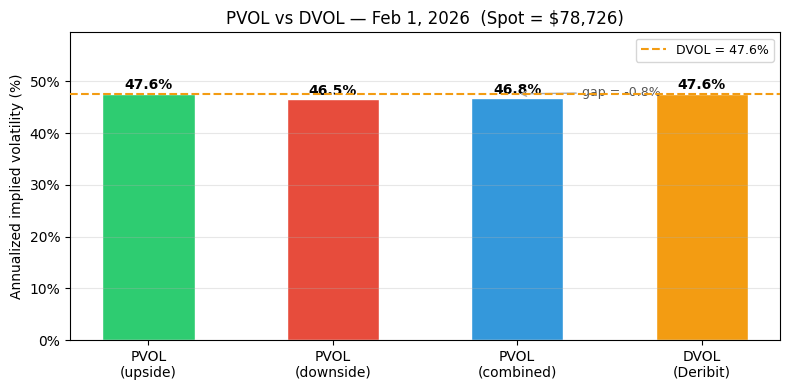

In [88]:
fig, ax = plt.subplots(figsize=(8, 4))

labels = ['PVOL\n(upside)', 'PVOL\n(downside)', 'PVOL\n(combined)', 'DVOL\n(Deribit)']
values = [pvol_up, pvol_down, pvol_combined, dvol]
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

bars = ax.bar(labels, [v * 100 for v in values], color=colors, edgecolor='white', width=0.5)

# Reference line at DVOL
ax.axhline(dvol * 100, color='#f39c12', linestyle='--', linewidth=1.5,
           label=f'DVOL = {dvol:.1%}', zorder=5)

# Annotate bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Gap annotation on the combined bar
ax.annotate(
    f'gap = {gap:+.1%}',
    xy=(2, dvol * 100),
    xytext=(2.35, (pvol_combined + dvol) / 2 * 100),
    fontsize=9, color='#555555',
    arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=1.0),
)

ax.set_ylabel('Annualized implied volatility (%)')
ax.set_title(f'PVOL vs DVOL — Feb 1, 2026  (Spot = ${SPOT:,.0f})')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.set_ylim(0, max(values) * 100 * 1.25)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()